In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
DATA_DIR = "."
FILE_X = "iPhone Thing-Accelerometer_X.csv"
FILE_Y = "iPhone Thing-Accelerometer_Y.csv"
FILE_Z = "iPhone Thing-Accelerometer_Z.csv"

In [8]:
def load_axis(filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)
    cols = list(df.columns)
    time_col = next((c for c in cols if "time" in c.lower()), cols[0])
    value_col = next((c for c in cols if c != time_col), cols[1])
    df = df.rename(columns={time_col: "time", value_col: "value"})
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)
    return df

In [10]:
df_x = load_axis(FILE_X)
df_y = load_axis(FILE_Y)
df_z = load_axis(FILE_Z)

print(len(df_x), len(df_y), len(df_z))
df_x.head()

1427 1424 1427


,time,value
0,2026-09-12 05:21:17.251000+00:00,0.009277
1,2026-09-12 05:21:18.252000+00:00,0.009857
2,2026-09-12 05:21:19.266000+00:00,0.008575
3,2026-09-12 05:21:20.266000+00:00,0.008820
4,2026-09-12 05:21:21.266000+00:00,0.010132


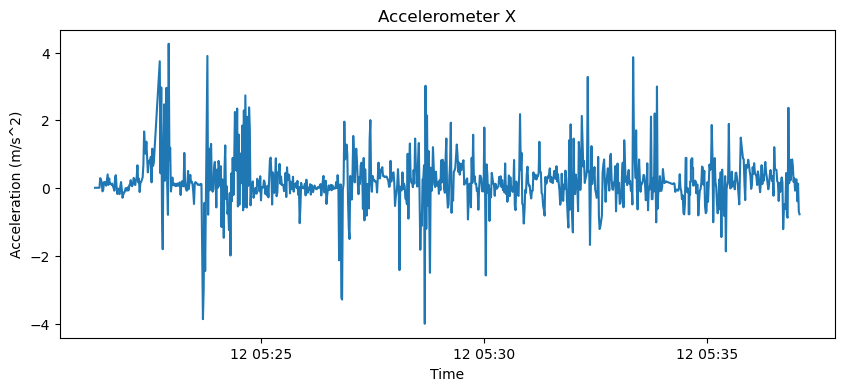

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(df_x["time"], df_x["value"], color="tab:blue")
plt.title("Accelerometer X")
plt.xlabel("Time")
plt.ylabel("Acceleration (m/s^2)")
plt.show()

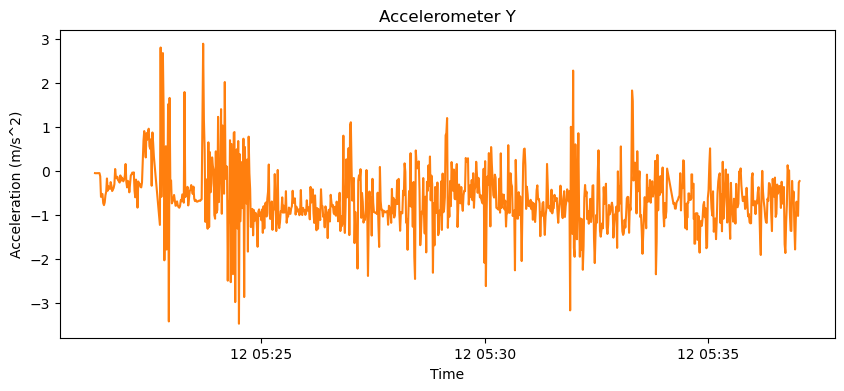

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(df_y["time"], df_y["value"], color="tab:orange")
plt.title("Accelerometer Y")
plt.xlabel("Time")
plt.ylabel("Acceleration (m/s^2)")
plt.show()

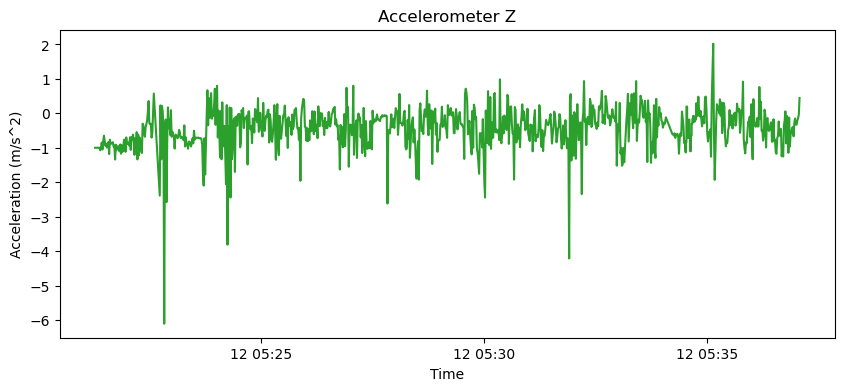

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(df_z["time"], df_z["value"], color="tab:green")
plt.title("Accelerometer Z")
plt.xlabel("Time")
plt.ylabel("Acceleration (m/s^2)")
plt.show()

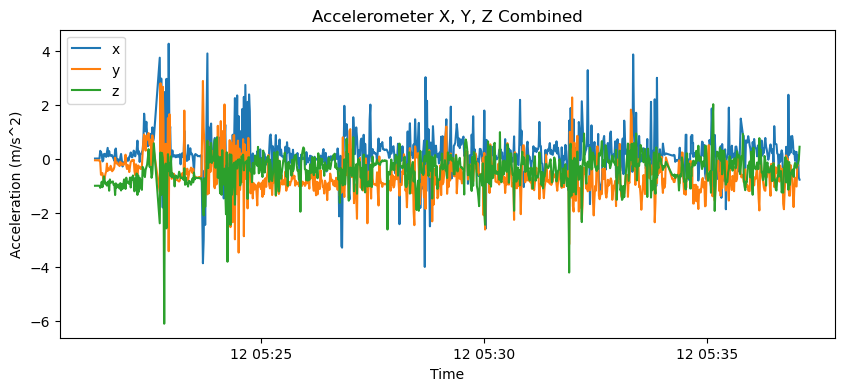

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(df_x["time"], df_x["value"], label="x", color="tab:blue")
plt.plot(df_y["time"], df_y["value"], label="y", color="tab:orange")
plt.plot(df_z["time"], df_z["value"], label="z", color="tab:green")
plt.title("Accelerometer X, Y, Z Combined")
plt.xlabel("Time")
plt.ylabel("Acceleration (m/s^2)")
plt.legend()
plt.show()